# How can we optimize patient wait times in Hospitals?

### Our Goal

Our goal is to analyze and predict Emergency Room wait times using to identify the key factors driving delays. By understanding which variables most significantly impact wait times such as urgency level, time of day, staffing ratios, and facility capacity hospitals can implement targeted interventions to reduce patient wait times and improve overall patient satisfaction. This analysis provides actionable insights that hospitals can use to optimize resource allocation, adjust staffing schedules, and streamline ER processes.


In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

### Data Loading

In [ ]:
df = pd.read_csv('ER_Wait_Time_Dataset.csv') # load the dataset
print("Dataset shape:", df.shape) # display basic information
print(df.head()) # display the first few rows
print(df.columns.tolist()) # display the column names
print(df.dtypes) # display the data types
print(df.describe()) # display the basic statistics

Dataset shape: (5000, 19)
               Visit ID Patient ID Hospital ID                 Hospital Name  \
0  HOSP-1-20240210-0001  PAT-00001      HOSP-1  Springfield General Hospital   
1  HOSP-3-20241128-0001  PAT-00002      HOSP-3  Northside Community Hospital   
2  HOSP-3-20240930-0002  PAT-00003      HOSP-3  Northside Community Hospital   
3  HOSP-2-20240227-0001  PAT-00004      HOSP-2      Riverside Medical Center   
4  HOSP-1-20240306-0002  PAT-00005      HOSP-1  Springfield General Hospital   

  Region           Visit Date Day of Week  Season   Time of Day Urgency Level  \
0  Urban  2024-02-10 20:20:56    Saturday  Winter  Late Morning        Medium   
1  Rural  2024-11-28 02:07:47    Thursday    Fall       Evening        Medium   
2  Rural  2024-09-30 04:02:28      Monday    Fall       Evening           Low   
3  Urban  2024-02-27 00:31:13     Tuesday  Winter       Evening          High   
4  Urban  2024-03-06 16:52:26   Wednesday  Spring     Afternoon           Low   

   Nur

In [102]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())
print("\nTarget variable stats:")
print(df['Total Wait Time (min)'].describe())

Missing values:
 Visit ID                              0
Patient ID                            0
Hospital ID                           0
Hospital Name                         0
Region                                0
Visit Date                            0
Day of Week                           0
Season                                0
Time of Day                           0
Urgency Level                         0
Nurse-to-Patient Ratio                0
Specialist Availability               0
Facility Size (Beds)                  0
Time to Registration (min)            0
Time to Triage (min)                  0
Time to Medical Professional (min)    0
Total Wait Time (min)                 0
Patient Outcome                       0
Patient Satisfaction                  0
dtype: int64

Target variable stats:
count    5000.000000
mean       81.916600
std        68.084538
min         4.000000
25%        27.000000
50%        60.000000
75%       122.000000
max       442.000000
Name: Total Wait T

The dataset contains **no missing values** across all 19 columns and 5,000 rows, so no imputation or data cleaning is required.

### Exploratory Data Analysis

The correlation heatmap only includes numeric columns because correlation measures linear relationships between quantitative values. Categorical columns like Region, Urgency Level, and Time of Day are excluded here since they contain text, they're encoded into numbers later in the Feature Engineering step before being used in the model.

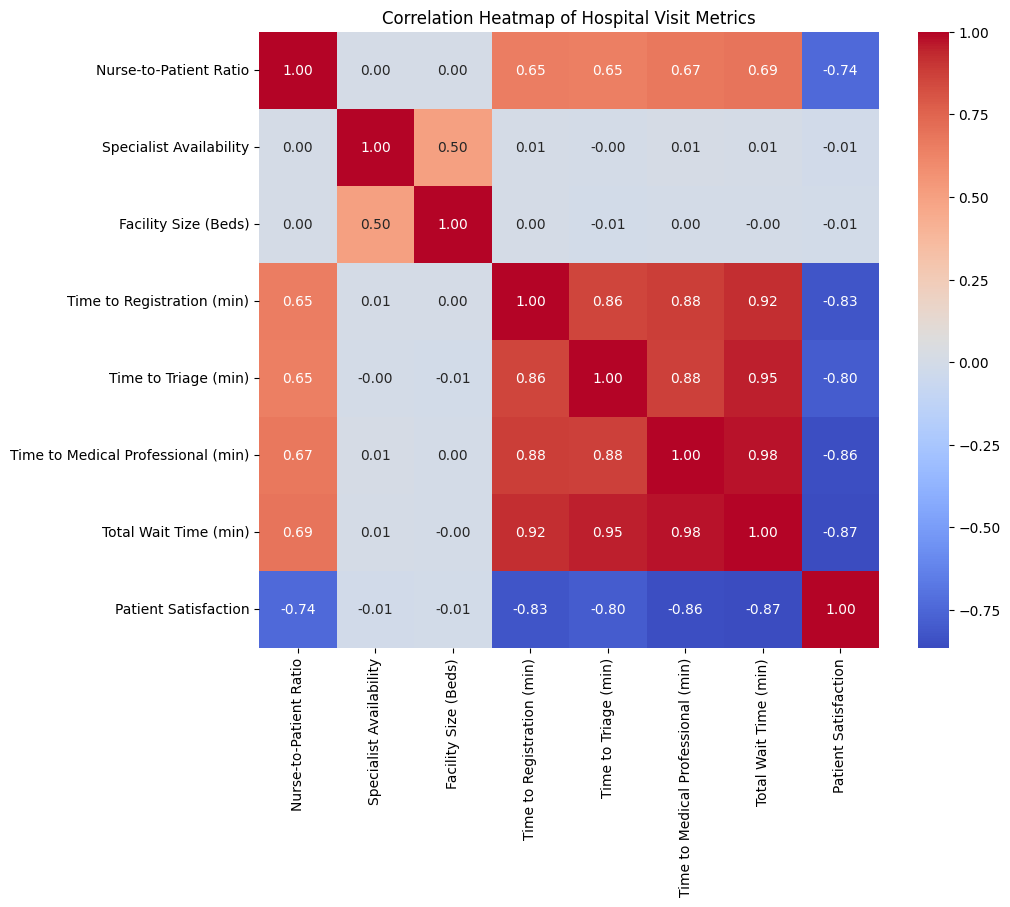

In [ ]:
# compute the correlation matrix using only numeric columns
numeric_cols = [
    'Nurse-to-Patient Ratio', 
    'Specialist Availability', 
    'Facility Size (Beds)',
    'Time to Registration (min)', 
    'Time to Triage (min)', 
    'Time to Medical Professional (min)', 
    'Total Wait Time (min)', 
    'Patient Satisfaction'
]

# Compute correlation matrix
corr = df[numeric_cols].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Hospital Visit Metrics")
plt.show()

The three process time columns:
**Time to Registration**, **Time to Triage**, and **Time to Medical Professional**
These are the strongest drivers of total wait time (correlations of 0.92, 0.95, and 0.98 respectively), which makes sense since total wait time is largely the sum of these stages. **Patient Satisfaction** has a strong negative correlation (-0.87), confirming that longer waits directly hurt patient experience. 
**Nurse-to-Patient Ratio** shows a moderate positive correlation (0.69), meaning fewer nurses per patient leads to longer waits. 
**Facility Size** and **Specialist Availability** have near-zero correlations with wait time, suggesting these factors alone don't meaningfully predict delays.

**Facility Size (Beds)** and **Specialist Availability** can be ruled out as meaningful predictors of wait time. With correlations of -0.004 and 0.007 respectively, they show no meaningful relationship with Total Wait Time. Because of this, these two features are excluded from the model. Keeping them would only add noise without improving predictions.

In [104]:
# Check what Time of Day values exist
print("Unique 'Time of Day' values:")
print(df['Time of Day'].unique())
print("\nValue counts:")
print(df['Time of Day'].value_counts())

Unique 'Time of Day' values:
<StringArray>
['Late Morning', 'Evening', 'Afternoon', 'Night', 'Early Morning']
Length: 5, dtype: str

Value counts:
Time of Day
Evening          1725
Afternoon        1502
Late Morning      770
Night             530
Early Morning     473
Name: count, dtype: int64


In [110]:
df['Process Sum'] = (
    df['Time to Registration (min)'] +
    df['Time to Triage (min)'] +
    df['Time to Medical Professional (min)']
)

df['Reg %'] = df['Time to Registration (min)'] / df['Total Wait Time (min)']
df['Triage %'] = df['Time to Triage (min)'] / df['Total Wait Time (min)']
df['Doctor %'] = df['Time to Medical Professional (min)'] / df['Total Wait Time (min)']

contributions = df[['Reg %', 'Triage %', 'Doctor %']].mean()

print(contributions)

Reg %       0.137531
Triage %    0.274616
Doctor %    0.587853
dtype: float64


In [111]:
avg_times = df[[
    'Time to Registration (min)', 
    'Time to Triage (min)', 
    'Time to Medical Professional (min)'
]].mean()

print("\nAverage Time per Stage (minutes):")
print(avg_times)


Average Time per Stage (minutes):
Time to Registration (min)            11.7042
Time to Triage (min)                  24.8270
Time to Medical Professional (min)    45.3854
dtype: float64


In [112]:
std_times = df[[
    'Time to Registration (min)', 
    'Time to Triage (min)', 
    'Time to Medical Professional (min)'
]].std()

print("\nStandard Deviation (variability):")
print(std_times)


Standard Deviation (variability):
Time to Registration (min)            10.437284
Time to Triage (min)                  24.807994
Time to Medical Professional (min)    35.619975
dtype: float64


In [113]:
peak_analysis = df.groupby('Time of Day')[[
    'Time to Registration (min)', 
    'Time to Triage (min)', 
    'Time to Medical Professional (min)'
]].mean()

print("\nAverage Stage Times by Time of Day:")
print(peak_analysis)


Average Stage Times by Time of Day:
               Time to Registration (min)  Time to Triage (min)  \
Time of Day                                                       
Afternoon                       11.615846             24.346871   
Early Morning                    7.103594             15.754757   
Evening                         14.325217             30.135652   
Late Morning                     9.758442             20.851948   
Night                           10.356604             22.781132   

               Time to Medical Professional (min)  
Time of Day                                        
Afternoon                               44.587883  
Early Morning                           29.230444  
Evening                                 55.247536  
Late Morning                            37.489610  
Night                                   41.435849  


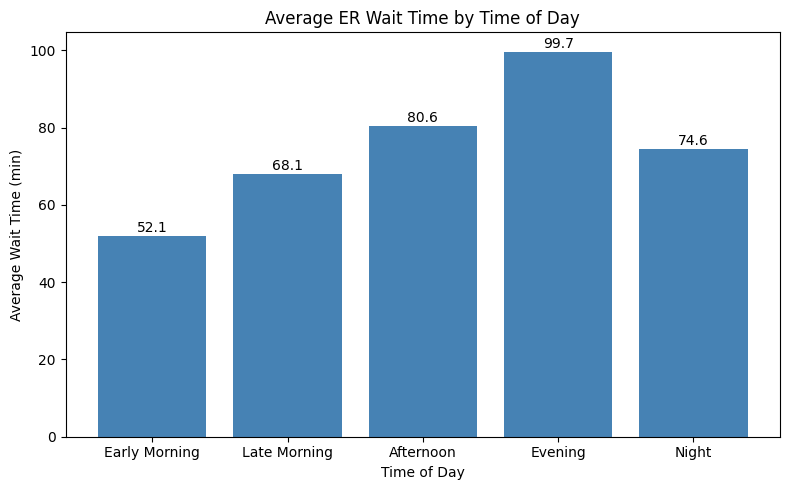

In [114]:
# Average wait time by time of day
time_order = ['Early Morning', 'Late Morning', 'Afternoon', 'Evening', 'Night']
avg_wait_tod = df.groupby('Time of Day')['Total Wait Time (min)'].mean().reindex(time_order)

plt.figure(figsize=(8, 5))
bars = plt.bar(avg_wait_tod.index, avg_wait_tod.values, color='steelblue')
plt.xlabel('Time of Day')
plt.ylabel('Average Wait Time (min)')
plt.title('Average ER Wait Time by Time of Day')
for bar, val in zip(bars, avg_wait_tod.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}', ha='center')
plt.tight_layout()
plt.show()

### Wait Time by Time of Day

This chart shows the average ER wait time broken down by time of day. Identifying peak hours is one of the most actionable insights a hospital can use, if Evening consistently shows the longest waits, that's a direct signal to increase staffing during those hours rather than spreading resources evenly across the day.
We can clearly see that the evening wait times are the worst for most ER's.

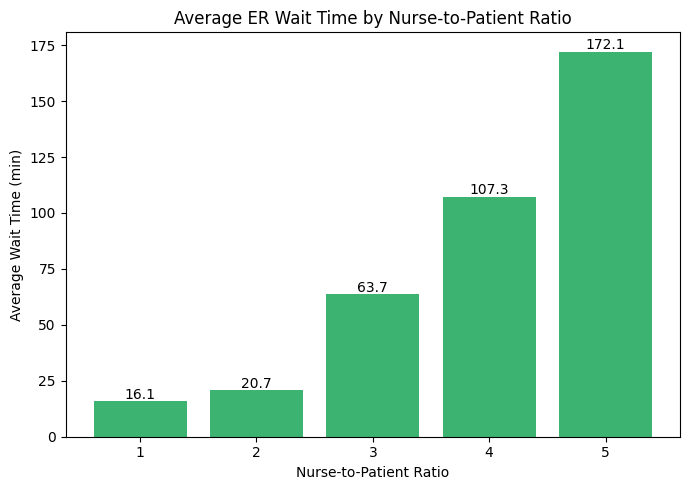

In [115]:
# Average wait time by nurse-to-patient ratio
avg_wait_nurse = df.groupby('Nurse-to-Patient Ratio')['Total Wait Time (min)'].mean()

plt.figure(figsize=(7, 5))
bars = plt.bar(avg_wait_nurse.index.astype(str), avg_wait_nurse.values, color='mediumseagreen')
plt.xlabel('Nurse-to-Patient Ratio')
plt.ylabel('Average Wait Time (min)')
plt.title('Average ER Wait Time by Nurse-to-Patient Ratio')
for bar, val in zip(bars, avg_wait_nurse.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}', ha='center')
plt.tight_layout()
plt.show()

### Wait Time by Nurse-to-Patient Ratio

This chart shows how staffing levels affect wait time. A clear downward trend (more nurses = shorter waits) would directly support the case for increased hiring or better shift scheduling. Even a modest reduction in wait time per additional nurse translates to a meaningful improvement in patient experience at scale.

## Feature Engineering & Encoding

Machine learning models work with numbers, not text. We need to convert categorical and ordinal features into numeric values:

- **Ordinal Encoding**: For features with natural order (Urgency: Low → High, Time of Day: Morning → Night), we map them to increasing numbers
- **Label Encoding**: For categorical features without order (Region: Urban/Rural), we assign numeric labels
- **Binary Features**: For yes/no questions (Is Weekend?), we use 0 or 1

This allows the model to understand relationships between these features and wait time.

In [ ]:
# Encode ordinal features
urgency_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
df['Urgency Encoded'] = df['Urgency Level'].map(urgency_map)

time_map = {'Morning': 1, 'Late Morning': 2, 'Afternoon': 3, 'Evening': 4, 'Night': 5}
df['Time Encoded'] = df['Time of Day'].map(time_map)

season_map = {'Spring': 1, 'Summer': 2, 'Fall': 3, 'Winter': 4}
df['Season Encoded'] = df['Season'].map(season_map)

# Encode categorical features
df['Region Encoded'] = LabelEncoder().fit_transform(df['Region'])
df['Is Weekend'] = df['Day of Week'].isin(['Saturday', 'Sunday']).astype(int)

# Select features for the model
# Facility Size (Beds) and Specialist Availability excluded — near-zero correlation with wait time
features = [
    'Urgency Encoded',
    'Nurse-to-Patient Ratio',
    'Time Encoded',
    'Season Encoded',
    'Region Encoded',
    'Is Weekend',
]

# Drop rows where any encoding produced NaN
df_clean = df[features + ['Total Wait Time (min)']].dropna()
print(f"Rows after dropping NaN: {len(df_clean)} (dropped {len(df) - len(df_clean)})")

X = df_clean[features]
y = df_clean['Total Wait Time (min)']

print("Features shape:", X.shape)
print(X.head())

## Linear Regression Model

## How the Model Works

The linear regression model compares total wait time with 8 features by learning a coefficient (weight) for each feature that shows how much it impacts wait time.

**The Model Formula:**
```
Predicted Wait Time = (baseline) 
                    + (coefficient₁ × Feature₁)
                    + (coefficient₂ × Feature₂)
                    + ... and so on for all 8 features
```

**What the Coefficients Mean:**
- **Negative coefficients** = that feature reduces wait time (e.g., higher urgency cases are seen faster, weekends have shorter waits)
- **Positive coefficients** = that feature increases wait time (e.g., evening times have longer waits)
- **Larger absolute values** = stronger impact on wait time

The model learns these coefficients by analyzing the entire dataset and finding the best values that minimize prediction errors. The resulting R² score of ~0.75 means the model explains about 75% of the variation in wait times, with the remaining 25% due to factors not captured in these 8 features.

In [105]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} minutes")
print(f"RMSE: {rmse:.2f} minutes")
print(f"R² Score: {r2:.4f}")

MAE: 24.56 minutes
RMSE: 35.23 minutes
R² Score: 0.7521


In [106]:
# Feature coefficients — which factors drive wait time?
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("Feature Coefficients (impact on Total Wait Time):")
print(coef_df.to_string(index=False))

Feature Coefficients (impact on Total Wait Time):
                Feature  Coefficient
        Urgency Encoded   -56.803161
             Is Weekend   -20.172454
           Time Encoded     8.535387
         Season Encoded     6.759872
 Nurse-to-Patient Ratio    -3.592331
         Region Encoded     0.646547
Specialist Availability    -0.141549
   Facility Size (Beds)    -0.005053


## Random Forest

### How the Model Works
Random Forest predicts ER wait time by building many decision trees that learn different patterns in the data (like how urgency, time, and staffing interact) and then averaging their predictions to produce a more accurate and robust estimate.

In [107]:
from sklearn.ensemble import RandomForestRegressor

# Initialize model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

In [108]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print(f"MAE: {mae_rf:.2f} minutes")
print(f"RMSE: {rmse_rf:.2f} minutes")
print(f"R² Score: {r2_rf:.4f}")

Random Forest Performance:
MAE: 15.05 minutes
RMSE: 24.27 minutes
R² Score: 0.8823


In [109]:
print("\nModel Comparison:")
print(f"Linear Regression RMSE: {rmse:.2f}")
print(f"Random Forest RMSE: {rmse_rf:.2f}")

print(f"Linear Regression R²: {r2:.4f}")
print(f"Random Forest R²: {r2_rf:.4f}")


Model Comparison:
Linear Regression RMSE: 35.23
Random Forest RMSE: 24.27
Linear Regression R²: 0.7521
Random Forest R²: 0.8823
